**Quantum variance simulation**

This program simulates M identical stocks using the quantum model, and plots some of the variance properties. 

Functions to generate points (z,v) for different periods T.

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import binned_statistic, norm, skewnorm


def generate_multi_period_dataset(t_periods_list, n_days=100000, sigma=0.1):
    """
    Loops over a list of period lengths T, runs the simulation for each,
    and returns a single combined DataFrame.
    
    Parameters:
    - t_periods_list (list of int): List of T values to simulate (e.g., 5*[1, 2, 4, 8, 16, 32])
    - n_days (int): Total number of days to divide for each simulation
    - sigma (float): Base standard deviation parameter
    
    Returns:
    - pd.DataFrame: Combined DataFrame containing rows from all simulated periods
    """
    # Use a list to collect DataFrames (much faster than repeatedly appending to a single DataFrame)
    dfs = []
    
    for t in t_periods_list:
        #print(f"Simulating period T = {t}...")
        df_t = simulate_q_periods(n_days=n_days, t_period=t, sigma=sigma)
        dfs.append(df_t)
        
    # Combine all individual DataFrames into a single giant DataFrame
    # ignore_index=True resets the index across the combined rows
    combined_df = pd.concat(dfs, ignore_index=True)
    
    return combined_df

def simulate_q_periods(n_days=100000, t_period=100, sigma=0.1):
    # calculate z, v for periods of length t_period
    num_periods = int(n_days // t_period)
    #vv = 3.5*sigma**4  # variance of variance var(v|z) for any z is 3.5*sigma**4 boost to give higher CV
    
    z_periods = np.zeros(num_periods)
    v_periods = np.zeros(num_periods)
    t_periods = np.full(num_periods, t_period)
    
    for i in range(num_periods):
        state_n = np.random.poisson(lam=0.5)
        sigma_n = sigma * np.sqrt(2 * state_n + 1)
        z_period = np.random.normal(loc=0.0, scale=sigma_n)
        
        expected_variance = sigma**2 + 0.5 * (z_period**2)  # from q-variance
        scale_param = 0.7928
        adjusted_loc = calculate_norm_loc(expected_variance, scale_param)  # using normal for log(v)
        actual_variance = np.exp(norm.rvs(loc=adjusted_loc, scale=scale_param))  # draws value of v
        measured_v = compute_measured_variance(actual_variance, t_period) # note this assumes that z series is normal, it isn't
        
        z_periods[i] = z_period 
        v_periods[i] = measured_v  # actual_variance  # 

    df = pd.DataFrame({
        'z': z_periods,
        'v': v_periods,
        't': t_periods,            # period length
        'i': range(num_periods)    # period number for this length
    })
    
    return df



def compute_measured_variance(actual_variance, t_period):
    """
    Computes a measured sample variance based on a period's true variance 
    and the number of days, assuming normal log returns (lognormal prices).
    
    Parameters:
    actual_variance (float): The expected/true variance over the total period T.
    t_period (int/float): The number of days (data points) in the period.
    
    Returns:
    float: A randomly sampled measured variance for that period.
    """
    # 1. Define degrees of freedom (k)
    # If the daily mean return is estimated from the data, k = n - 1.
    # If returns are strictly demeaned around a known mean of 0, k = t_period.
    degrees_of_freedom = t_period - 1 
    
    # 2. Draw a random sample from the standard Chi-Squared distribution
    chi2_sample = np.random.chisquare(df=degrees_of_freedom)
    
    # 3. Scale the standard sample back into actual variance units
    # Formula: measured_variance = (actual_variance / k) * chi2_sample
    measured_variance = (actual_variance / degrees_of_freedom) * chi2_sample
    
    return measured_variance



target_periods = 5*(np.arange(26)+1)   # does 1 to 26 weeks, can also do [5, 10, 20, 40, 80, 160] or 5*2**np.arange(0, 12) 

# Generate the master dataframe
sigma0SP = 0.137  # use this for comparison with SP500 index
sigma0 = 0.259  # convergence is slower for low sigma0
#sigma0 = sigma0SP
#n_days = 5000  #5*int(2**10)  # 2**10=1024  # length for each tick
n_days_vec = np.random.uniform(4902, 15864, 401)  # varies over same range as SP500 data

n_tick = 100  # max 100 for Jupyter
df = []

gamma = 0
scale_param = gamma*sigma0**2 # np.sqrt(3.5)*sigma0**2  # increase this for inter-stock variability
adjusted_loc = calculate_norm_loc(sigma0**2, scale_param) 

actual_variance = np.zeros(n_tick)
for n in range(n_tick):
    actual_variance[n] = np.exp(norm.rvs(loc=adjusted_loc, scale=scale_param))  # draws value of v
    if n == 0:
        actual_variance[n] = sigma0**2
    dfcur = generate_multi_period_dataset(t_periods_list=target_periods, n_days=n_days_vec[n], sigma=np.sqrt(actual_variance[n]))
    dfcur["tick"] = int(n)
    df.append(dfcur)

df = pd.concat(df, ignore_index=True)
cv0 = np.std(actual_variance)/np.mean(actual_variance)
print(f"{cv0=}")  # CV of min variance is 0.35, for stocks is about 0.53

# Now bin the data
bins = np.arange(-0.625, 0.675, 0.05)
#df['bin_mid'] = pd.cut(df['z'], bins).apply(lambda z: z.mid).astype(float)
df['bin_mid'] = pd.cut(df['z'], bins).apply(lambda z: z.mid if pd.notnull(z) else np.nan).astype(float)
# Note: depending on your pandas version, you can also use:
# df['bin_mid'] = pd.cut(df['z'], bins).array.mid

binned_summary = df.groupby('bin_mid', observed=True)['v'].mean().reset_index()  # columns bin_mid, v

print(df.head(10))
print(df.tail(10))

print(f"\nFinal DataFrame Shape: {df.shape}")
#print(df.sample(5)) # View 5 random rows across different T values


cv0=np.float64(2.0688105138287227e-17)
          z         v  t  i  tick  bin_mid
0 -1.879446  0.886581  5  0     0      NaN
1  0.424879  0.115128  5  1     0     0.40
2 -0.227269  0.087156  5  2     0    -0.25
3 -0.012021  0.049013  5  3     0     0.00
4 -0.401197  0.052457  5  4     0    -0.40
5 -0.080975  0.060548  5  5     0    -0.10
6  0.329719  0.025524  5  6     0     0.35
7  0.357438  0.027223  5  7     0     0.35
8  0.171452  0.170251  5  8     0     0.15
9 -0.075987  0.094978  5  9     0    -0.10
               z         v    t    i  tick  bin_mid
778142  0.037607  0.043609  130   98    99     0.05
778143  0.341630  0.310322  130   99    99     0.35
778144 -0.392148  0.382954  130  100    99    -0.40
778145 -0.115826  0.142382  130  101    99    -0.10
778146 -0.343834  0.064365  130  102    99    -0.35
778147  0.121542  0.031470  130  103    99     0.10
778148 -0.369918  0.172167  130  104    99    -0.35
778149  0.255255  0.189283  130  105    99     0.25
778150 -0.119893  0.

Now plot the q-variance curve for each stock.

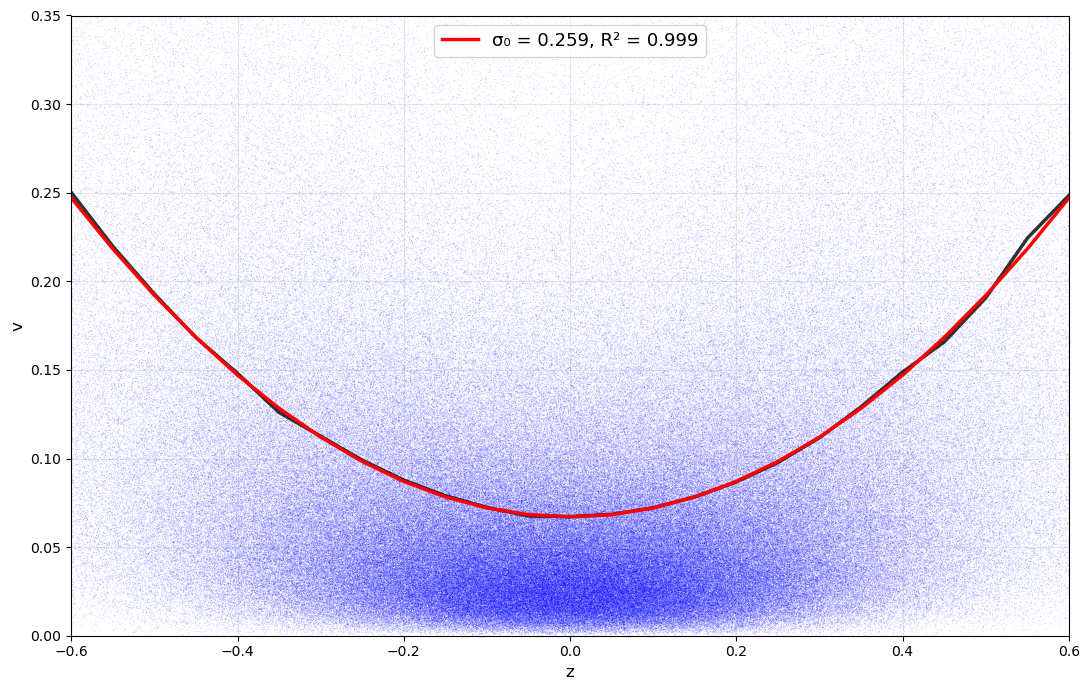

In [29]:
def q_variance_model(z, sigma_0_sq):
    return sigma_0_sq + z**2 / 2


fig, ax = plt.subplots(figsize=(11, 7))  # Slightly widened to make room for the colorbar

# Map the 't' column to the 'c' parameter and choose a colormap (e.g., 'viridis', 'plasma', or 'coolwarm')
#scatter = ax.scatter(df['z'],  df['v'], c=df['t'], cmap='viridis', alpha=0.2, s=1, edgecolors='none')
scatter = ax.scatter(df['z'],  df['v'], color='blue', alpha=0.2, s=0.4, edgecolors='none')

qvarcurve = q_variance_model(binned_summary['bin_mid'], sigma0**2)
ss_res = np.sum((binned_summary['v'] - qvarcurve)**2)
ss_tot = np.sum((binned_summary['v'] - np.mean(binned_summary['v']))**2)
r_squared = 1 - ss_res / ss_tot

# Plot the total binned summary
ax.plot(binned_summary['bin_mid'], binned_summary['v'], color='black', linewidth=2.5, alpha=0.8)

# Plot the q-variance curve
ax.plot(binned_summary['bin_mid'], qvarcurve,
         color='red', lw=2.5,
         label=f'σ₀ = {sigma0:.3f}, R² = {r_squared:.3f}')

# Add a colorbar to act as a legend for the continuous T values
#cbar = fig.colorbar(scatter, ax=ax, pad=0.02)
#cbar.set_label('Period Length (T)', fontsize=12)

# Axis limits and labels
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(0, 0.35)
ax.set_xlabel('z', fontsize=12)
ax.set_ylabel('v', fontsize=12)

ax.grid(alpha=0.3)

#plt.title('Quantum model, not from time series', fontsize=14)
plt.legend(fontsize=13, loc='upper center')
plt.tight_layout()#plt.savefig('Figure_1_N10.png', dpi=300, bbox_inches='tight')

plt.show()

Now plot log variance over all data.

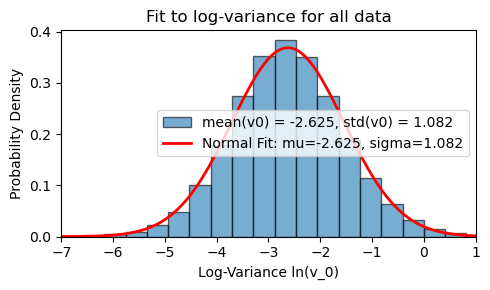

In [34]:
log_v = np.log(df['v'])  # log-transformed values
log_v = log_v[log_v > -7]

# plot the logged data histogram (using density=True for PDF matching)
fig, ax = plt.subplots(figsize=(5, 3))  # Slightly widened to make room for the colorbar
count, bins, ignored = ax.hist(
    log_v, 
    bins=25, 
    edgecolor='black', 
    alpha=0.6, 
    density=True, 
    label=f'mean(v0) = {np.mean(log_v):.3f}, std(v0) = {np.std(log_v):.3f}'
)

# 2. Fit the standard Normal distribution parameters to the log-transformed data
# This returns the empirical mean (mu) and empirical standard deviation (std)
mu_fitted, std_fitted = norm.fit(log_v)

# 3. Create a smooth range of x-values tracking across the log-scale axis
x_arr = np.linspace(min(log_v), max(log_v), 200)

# 4. Calculate the standard Normal PDF values over the log-range
pdf_fitted = norm.pdf(x_arr, loc=mu_fitted, scale=std_fitted)

# Overlay the fitted normal curve line directly
ax.plot(x_arr, pdf_fitted, 'r-', linewidth=2, label=f'Normal Fit: mu={mu_fitted:.3f}, sigma={std_fitted:.3f}')

# Add accurate axis labels, updated titles, and legend
ax.set_xlabel('Log-Variance ln(v_0)')
ax.set_ylabel('Probability Density')
ax.set_title('Fit to log-variance for all data')
ax.legend()
plt.xlim(-7, 1)
plt.tight_layout()
plt.show()

Now plot variance distribution for binned values of z.

Bin (-1.0, -0.9]: Coefficient of Variation = 1.0786, Mean = 0.5071, Std = 0.5470
Bin (-0.9, -0.7]: Coefficient of Variation = 1.1204, Mean = 0.3734, Std = 0.4184
Bin (-0.7, -0.5]: Coefficient of Variation = 1.1428, Mean = 0.2412, Std = 0.2756
Bin (-0.5, -0.3]: Coefficient of Variation = 1.1449, Mean = 0.1432, Std = 0.1639
Bin (-0.3, -0.1]: Coefficient of Variation = 1.1296, Mean = 0.0878, Std = 0.0991
Bin (-0.1, 0.1]: Coefficient of Variation = 1.1172, Mean = 0.0685, Std = 0.0765
Bin (0.1, 0.3]: Coefficient of Variation = 1.1424, Mean = 0.0871, Std = 0.0995
Bin (0.3, 0.5]: Coefficient of Variation = 1.1305, Mean = 0.1435, Std = 0.1623
Bin (0.5, 0.7]: Coefficient of Variation = 1.1216, Mean = 0.2428, Std = 0.2723
Bin (0.7, 0.9]: Coefficient of Variation = 1.0965, Mean = 0.3817, Std = 0.4185


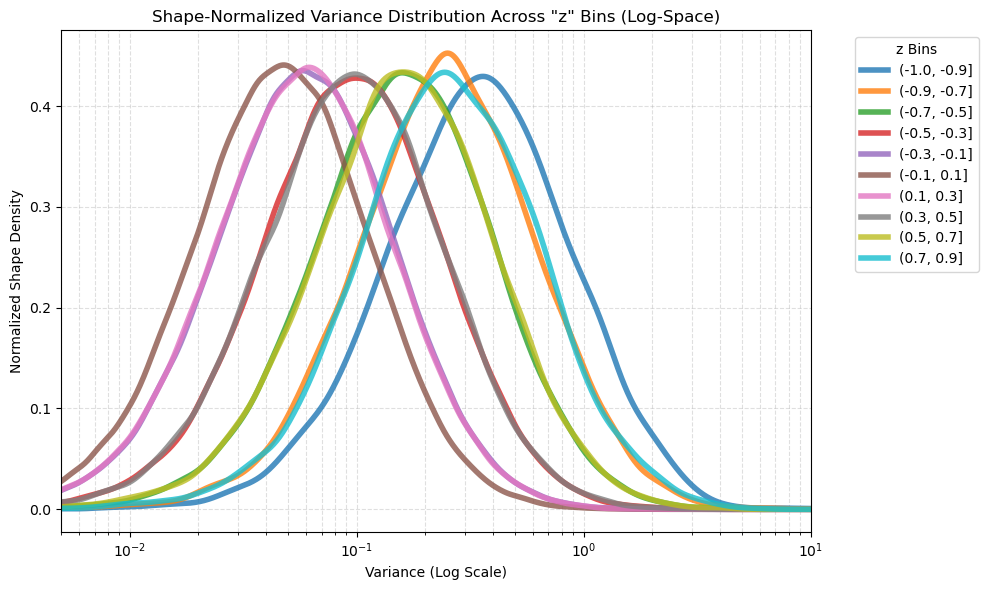

In [35]:
from scipy.stats import gaussian_kde
def analyze_variance_by_bin2(df):
    # 1. Define custom edges to handle z values from -1.0 to 1.0
    bin_edges = [-1.0001] + list(np.arange(-0.9, 1.01, 0.1*2))
    
    # 2. Bin the 'z' column
    df = df.copy()
    df['z_bin'] = pd.cut(df['z'], bins=bin_edges)
    
    # 3. Initialize the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # 4. Generate high-resolution log-evaluation grid to match your limits [5e-3, 10]
    # We evaluate directly in natural log space
    x_min, x_max = 5e-3, 10
    log_grid = np.linspace(np.log(x_min), np.log(x_max), num=1000)
    
    # 5. Process each bin sequentially
    for bin_interval, group in df.groupby('z_bin', observed=False):
        # Drop missing values and filter out non-positive values (cannot log 0 or negatives)
        var_data = group['v'].dropna()
        var_data = var_data[var_data > 0]
        
        if var_data.empty:
            continue
            
        # 6. Calculate Coefficient of Variation (CV = SD / Mean) on original data
        mean_val = var_data.mean()
        std_val = var_data.std()
        cv = std_val / mean_val
        print(f"Bin {bin_interval}: Coefficient of Variation = {cv:.4f}, Mean = {mean_val:.4f}, Std = {std_val:.4f}")
            
        # 7. LOG NORMALIZATION: Transform data to log-space to isolate shape 
        log_data = np.log(var_data)
        
        # Build a kernel density estimator in log-space
        # Handling edge cases where a bin might only have 1 distinct value
        try:
            kde = gaussian_kde(log_data)
            density_values = kde(log_grid)
        except np.linalg.LinAlgError:
            continue # Skip bins with zero variance in log-space
        
        # 8. Plot the normalized curves
        # np.exp(log_grid) maps the log evaluation points back to your 5e-3 to 10 scale
        ax.plot(
            np.exp(log_grid), 
            density_values, 
            label=str(bin_interval), 
            alpha=0.8, 
            linewidth=4
        )
    
    # 9. Finalize plot layout and labels
    ax.set_xscale('log')
    ax.set_xlim(x_min, x_max)
    ax.set_title('Shape-Normalized Variance Distribution Across "z" Bins (Log-Space)')
    ax.set_xlabel('Variance (Log Scale)')
    ax.set_ylabel('Normalized Shape Density')
    ax.legend(title='z Bins', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()

analyze_variance_by_bin2(df)

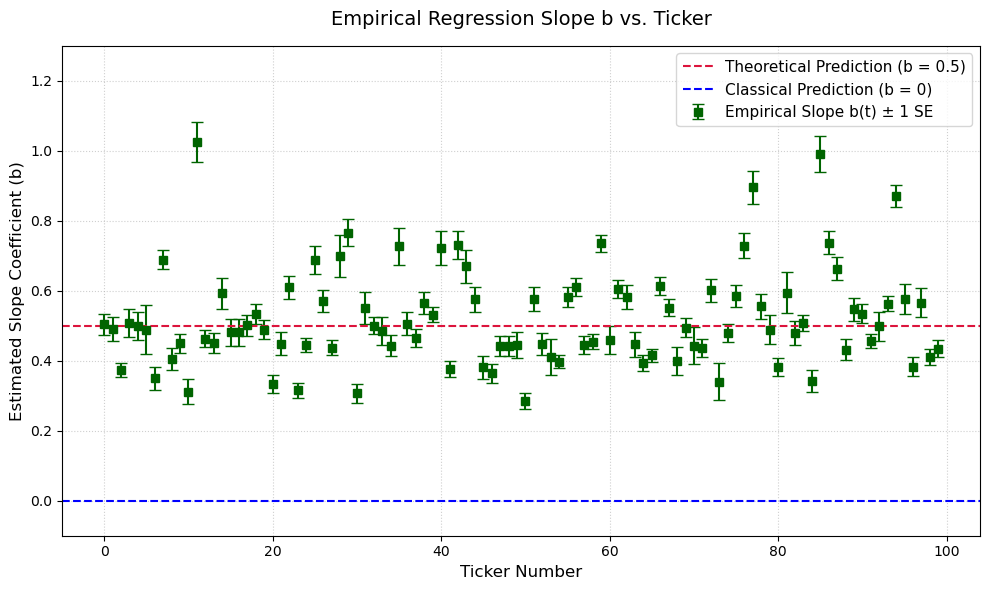

In [38]:
# now plot coef b vs ticker
import statsmodels.api as sm

def plot_slopes_stocks(dataframe):
    """
    Performs a linear regression y = a + b * z^2 for each period T,
    extracts the slope b(T), prints a summary table, and plots b(T) vs T.
    
    Parameters:
    - dataframe (pd.DataFrame): The master combined dataframe containing 'z', 'v', and 't'
    """
    # Group by the unique tickers present in the dataframe
    grouped = dataframe.groupby('tick')
    
    t_list = []
    b_list = []
    a_list = []
    slope_err_list = []
    
    for t_val, group in grouped:
        x = group['z']**2
        y = group['v']
        
        # np.polyfit(x, y, 1) fits a 1st-degree polynomial: y = slope * x + intercept
        # It handles ordinary least squares regression natively
        # slope, intercept = np.polyfit(x, y, 1)
        
        p, cov = np.polyfit(x, y, 1, cov=True)
        slope, intercept = p[0], p[1]

        # Extract standard errors from the diagonal of the covariance matrix
        # cov[0,0] corresponds to the variance of the slope
        slope_err = np.sqrt(cov[0, 0])
             
        t_list.append(t_val)
        b_list.append(slope)
        a_list.append(intercept)
        slope_err_list.append(slope_err)
        
        #print(f"{t_val:<12} | {intercept:<15.6f} | {slope:<15.4f} | {slope_err:<15.4f}")
        
        
    q_list = [0.5] * len(t_list)  # compare with constant 0.5

    # --- Visualization Code ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot empirical slope values
    ticker_numbers = np.arange(len(t_list))
    ax.errorbar(ticker_numbers, b_list, yerr=slope_err_list, fmt='s', markersize=6, 
                color='darkgreen', ecolor='darkgreen', elinewidth=1.5, capsize=4,
                linestyle='None', linewidth=2, label='Empirical Slope b(t) ± 1 SE')
    
    # Plot the expected theoretical horizontal line
    ax.axhline(y=0.5, color='crimson', linestyle='--', linewidth=1.5, 
               label='Theoretical Prediction (b = 0.5)')
    ax.axhline(y=0.0, color='blue', linestyle='--', linewidth=1.5, 
               label='Classical Prediction (b = 0)')
    
    # Visual Layout Polish
    ax.set_title(r'Empirical Regression Slope b vs. Ticker', fontsize=14, pad=15)  #  for $|z|<0.6
    ax.set_xlabel('Ticker Number', fontsize=12)
    ax.set_ylabel(r'Estimated Slope Coefficient (b)', fontsize=12)
    
    # Configure grid lines and legend
    ax.grid(True, linestyle=':', alpha=0.6)
    ax.legend(fontsize=11, loc='best')
    
    ax.set_ylim(-0.1, 1.3)
    
    plt.tight_layout()
    #plt.show()

# --- Execution ---
# select one period T=20 so data is not addected by correlations between sub-periods

df2 = df[df["t"] == 20] 
plot_slopes_stocks(df2)